Test different peak finding algorithms for the ISI data

1) Basic scipy.find_peaks()
    - Can sometimes find spurious peaks
    - Estimate of distribution parameters can be hacky
    - Need to smooth the data beforehand

2) GaussianMixture Model
    - fits gaussians to the data
    - identify the number of peaks by repeated for different values of n_components, pick
    the one with the highest BIC

3) BayesianGaussianMixture Model
    - will fit the minimum number of gaussians to the data...

In [1]:
from aqua.batchAQUA_general import batchAQUA
from aqua.AQUA_general import AQUA
from aqua.utils import * 
from aqua.plotting_functions import *
from aqua.stimulus import OU_current

'''general imports''' 
import numpy as np
import pandas as pd
from brian2 import *
import matplotlib.pyplot as plt
import seaborn as sns
import pyspike as spk
import pickle
import gc
import tracemalloc
from scipy.signal import convolve, windows
from scipy.stats import wasserstein_distance
from scipy.ndimage import gaussian_filter

from FT_metrics import *
from functions import *


WARNING    /home/liam/anaconda3/envs/aqua/lib/python3.14/site-packages/pyspike/__init__.py:40: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
 [py.warnings]


In [2]:
tag = 'test200'
filename = f"burst_analysis_{tag}.pickle"
with open(filename, 'rb') as file:
    data = pickle.load(file)

print(data.keys())

# import TRACES
filename = f"burst_analysis_{tag}TRACES.pickle"
with open(filename, 'rb') as file:
    traces = pickle.load(file)

spikes_E1 = traces["spikes_E1"]
spikes_E2 = traces["spikes_E2"]

isi_E1 = np.diff(spikes_E1, axis = 1)
isi_E2 = np.diff(spikes_E2, axis = 1)

X_E1 = traces["X_E1"]
X_E2 = traces["X_E2"]

f_vals = traces['f']
time = traces['time']
print("- - F_VALS - - ")
print(f_vals)

# neurons of interest
f4 = np.array([400, 420, 430, 440, 447]) 
idx4_arr = np.array([np.argmin(np.abs(f_vals - f)) for f in f4])

f2 = np.array([145, 150, 155, 165])                                      # represents the tiny bump in the middle
idx2_arr = np.array([np.argmin(np.abs(f_vals - f)) for f in f2])


Index(['sim_number', 'neuron_label', 'e', 'f', 'tau', 'I_inj', 'W',
       'FT_distance', 'FT_EMD', 'SPIKE_distance', 'SPIKE_synchrony',
       'spike_directionality', 'schreiber similarity', 'peak_isi',
       'peak_number', 'mean', 'std', 'count_sum', 'CV_isi', 'LV', 'entropy',
       'noise_theta', 'noise_sigma', 'num_peaks'],
      dtype='object')
- - F_VALS - - 
[  0.          10.          14.44444444  18.88888889  23.33333333
  27.77777778  32.22222222  36.66666667  41.11111111  45.55555556
  50.          54.44444444  58.88888889  63.33333333  67.77777778
  72.22222222  76.66666667  81.11111111  85.55555556  90.
  94.44444444  98.88888889 103.33333333 107.77777778 112.22222222
 116.66666667 121.11111111 125.55555556 130.         134.44444444
 138.88888889 143.33333333 147.77777778 152.22222222 156.66666667
 161.11111111 165.55555556 170.         174.44444444 178.88888889
 183.33333333 187.77777778 192.22222222 196.66666667 201.11111111
 205.55555556 210.         214.44444444 218.

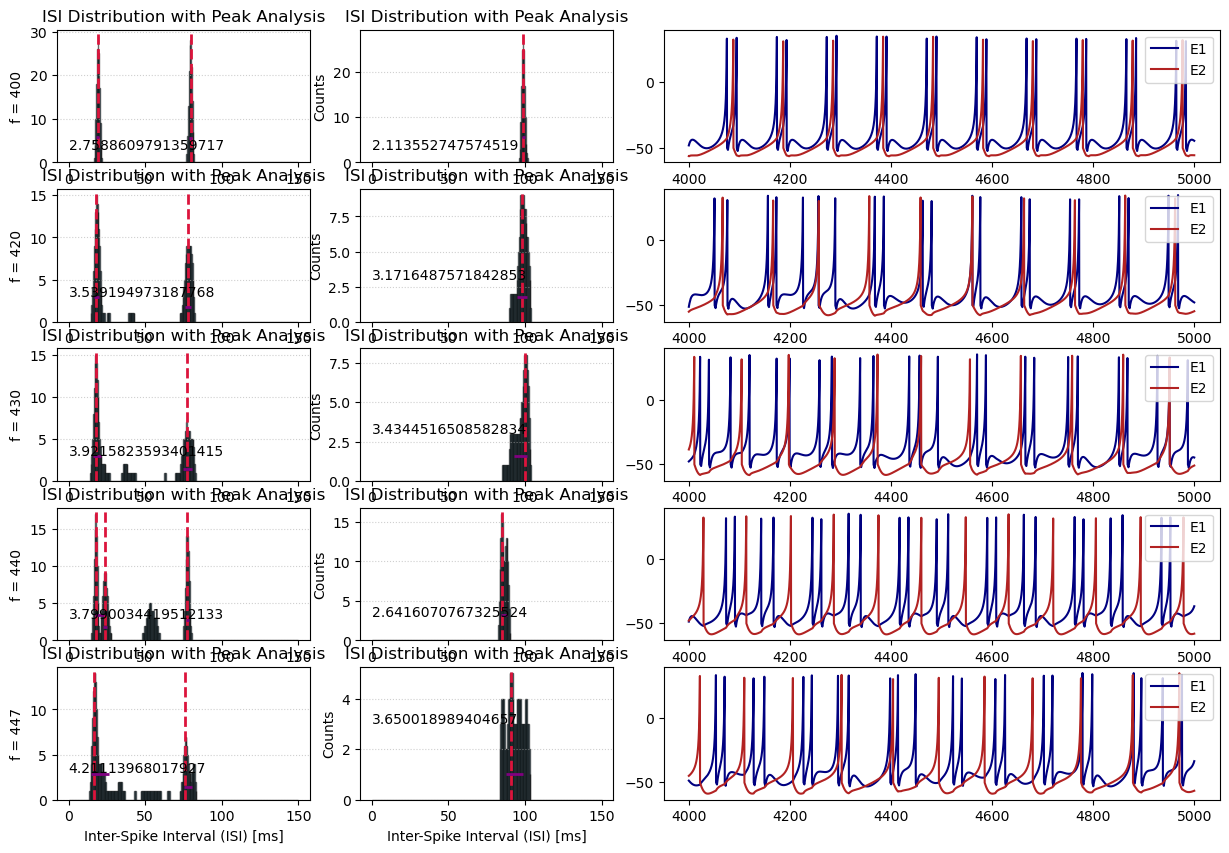

In [3]:
fig, ax = plot_peak_and_series(f4, idx4_arr, spikes_E1, spikes_E2, X_E1, X_E2, data, f_vals, time)

In [12]:
## Test the BGMM to the spiking data of interest
bins = 300
x_range = (0, 150)
threshold = 0.15

idx_lst = []
f_lst = []
neuron_labels = []
results_lst = []

for idx in idx4_arr:
    counts1, bin_edges1 = np.histogram(isi_E1[idx, :], bins = bins, range = x_range)
    counts2, bin_edges2 = np.histogram(isi_E2[idx, :], bins = bins, range = x_range)

    results1, meta1 = BGMM_peak_finding(isi_E1[idx, :], counts1, weight_threshold = threshold)
    results2, meta2 = BGMM_peak_finding(isi_E2[idx, :], counts2, weight_threshold = threshold)
    
    #print('- - META 1 - - ')
    #print(meta1)

    print('- - META 2 - - ')
    print(meta2)

    for result in results1:
        result['idx'] = idx
        result['f'] = f_vals[idx]
        result['neuron_label'] = 'E1'
        results_lst.append(result)
    
    for result in results2:
        result['idx'] = idx
        result['f'] = f_vals[idx]
        result['neuron_label'] = 'E2'
        results_lst.append(result)
    
    

print(results_lst)

df = pd.DataFrame(results_lst)


print(df.head())




- - META 2 - - 
{'detected_num_peaks': 1, 'active_weights': [0.9454013792225648]}
- - META 2 - - 
{'detected_num_peaks': 2, 'active_weights': [0.2187451489868152, 0.7715657549965202]}


WARNING    /home/liam/anaconda3/envs/aqua/lib/python3.14/site-packages/sklearn/mixture/_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
 [py.warnings]


- - META 2 - - 
{'detected_num_peaks': 2, 'active_weights': [0.4268031550302579, 0.5543587416762519]}
- - META 2 - - 
{'detected_num_peaks': 2, 'active_weights': [0.473764384769526, 0.4539488237384861]}


WARNING    /home/liam/anaconda3/envs/aqua/lib/python3.14/site-packages/sklearn/mixture/_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
 [py.warnings]


- - META 2 - - 
{'detected_num_peaks': 2, 'active_weights': [0.5089951374879894, 0.43683412909563296]}
[{'peak_isi': np.float64(19.319638318211375), 'mean': np.float64(19.319638318211375), 'std': np.float64(3.4774012398633243), 'proportion': np.float64(0.5029905532996525), 'estimated_count': np.float64(152.90912820309435), 'idx': np.int64(89), 'f': np.float64(401.11111111111114), 'neuron_label': 'E1'}, {'peak_isi': np.float64(79.27952006633124), 'mean': np.float64(79.27952006633124), 'std': np.float64(3.477194169129076), 'proportion': np.float64(0.477173058775965), 'estimated_count': np.float64(145.06060986789336), 'idx': np.int64(89), 'f': np.float64(401.11111111111114), 'neuron_label': 'E1'}, {'peak_isi': np.float64(98.69265475874323), 'mean': np.float64(98.69265475874323), 'std': np.float64(0.10754535775984923), 'proportion': np.float64(0.9454013792225648), 'estimated_count': np.float64(142.7556082626073), 'idx': np.int64(89), 'f': np.float64(401.11111111111114), 'neuron_label': 'E2

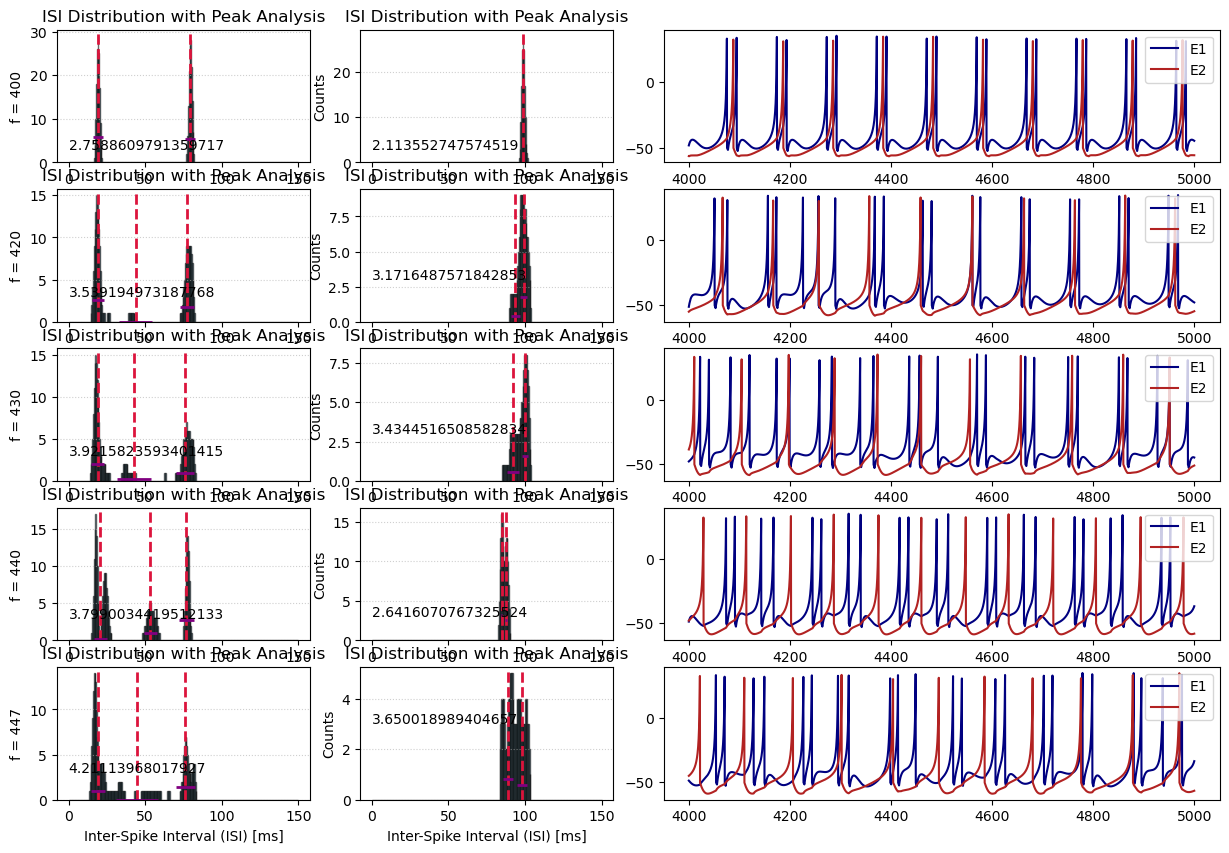

In [13]:
fig, ax = plot_peak_and_series(f4, idx4_arr, spikes_E1, spikes_E2, X_E1, X_E2, df, f_vals, time)